In [4]:
import pandas as pd


In [5]:
import matplotlib.pyplot as plt

In [6]:
#A simple function with dummy data
def score_label(score):
    if score >= 90:
        return "Excellent"
    if score >= 70:
        return "Good"
    if score >= 50:
        return "Pass"
    else:
        return "Fail"
    
score_label(90)

'Excellent'

In [7]:
#applying the function to synthetic data
df_scores = pd.DataFrame({
    "student": ["Anna", "Ben", "Chris", "Diana", "Eva"],
    "score": [95, 78, 61, 43, 88]
})

df_scores

,student,score
0,Anna,95
1,Ben,78
2,Chris,61
3,Diana,43
4,Eva,88


In [8]:
#option 1 with apply
df_scores["score_label"] = df_scores["score"].apply(score_label)
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [9]:
#option 2 with list comprehension
df_scores["score_label"] = [score_label(i) for i in df_scores["score"]]
df_scores

,student,score,score_label
0,Anna,95,Excellent
1,Ben,78,Good
2,Chris,61,Pass
3,Diana,43,Fail
4,Eva,88,Good


In [10]:
#default arguments
def classify_price(price, low=5, high=15):
    if price <= low:
        return "Low-range product"
    if price <= high:
        return "Mid-range product"
    else:
        return "High-range product"
    
classify_price(9)

'Mid-range product'

In [11]:
#Example 2: Synthetic Data for Product Price Segments
df_products_dummy = pd.DataFrame({
    "product": ["Milk", "Bread", "Juice", "Cheese", "Steak", "Apples"],
    "price": [2.5, 1.8, 6.2, 12.0, 24.5, 4.2]
})

df_products_dummy

,product,price
0,Milk,2.5
1,Bread,1.8
2,Juice,6.2
3,Cheese,12.0
4,Steak,24.5
5,Apples,4.2


In [12]:
df_products_dummy["price_range"] = df_products_dummy["price"].apply(classify_price)
df_products_dummy

,product,price,price_range
0,Milk,2.5,Low-range product
1,Bread,1.8,Low-range product
2,Juice,6.2,Mid-range product
3,Cheese,12.0,Mid-range product
4,Steak,24.5,High-range product
5,Apples,4.2,Low-range product


In [13]:
#Task 3
df_customers_dummy = pd.DataFrame({
    "customer": ["A", "B", "C", "D", "E"],
    "age": [22, 35, 47, 63, 29],
    "income": [18000, 42000, 72000, 95000, 25000]
})

df_customers_dummy



,customer,age,income
0,A,22,18000
1,B,35,42000
2,C,47,72000
3,D,63,95000
4,E,29,25000


In [14]:
#Task 1: 
def age_group_label(age):
    if age < 30:
        return "Young"
    elif age < 59:
        return "Middle"
    else:
        return "Senior"
    
df_customers_dummy["age_group"] = df_customers_dummy["age"].apply(age_group_label)
df_customers_dummy

,customer,age,income,age_group
0,A,22,18000,Young
1,B,35,42000,Middle
2,C,47,72000,Middle
3,D,63,95000,Senior
4,E,29,25000,Young


In [15]:
#Task 2:
def income_band(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"
    
df_customers_dummy["income_group"] = df_customers_dummy["income"].apply(income_band)
df_customers_dummy

,customer,age,income,age_group,income_group
0,A,22,18000,Young,Low income
1,B,35,42000,Middle,Middle income
2,C,47,72000,Middle,High income
3,D,63,95000,Senior,High income
4,E,29,25000,Young,Low income


In [16]:
#import package
pd.set_option('display.max_columns', None)

In [17]:
#reading the data
df_instacart = pd.read_csv('../data/processed/instacart.csv')

In [18]:
#Example 1: Creating a price_range Column
def price_label(row):
    if row["prices"] <= 5:
        return "Low-range product"
    elif row["prices"] <= 15:
        return "Mid-range product"
    elif row["prices"] > 15:
        return "High-range product"
    else:
        return "Not enough data"

In [19]:
df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [20]:
#Alternative: Creating the Same Column with .loc
pd.set_option('display.max_columns', None)

In [21]:
#Reading the data
df_instacart = pd.read_csv('../data/processed/instacart.csv')

In [22]:
#Creating a price_range column
def price_label(row):
    if row["prices"] <=5:
        return "Low-range product"
    if row["prices"] <=15:
        return "Mid-range product"
    if row["prices"] > 15:
        return "High-range product"
    else:
        return "Not enough data"

In [23]:
#Now we apply the function row by row.
df_instacart["price_range"] = df_instacart.apply(price_label, axis=1)
df_instacart["price_range"].value_counts(dropna=False)

price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [24]:
#Once the derived column is created, we can inspect the result.
df_instacart["price_range"].value_counts(dropna=False)


price_range
Mid-range product     936243
Low-range product     430870
High-range product     17505
Not enough data           88
Name: count, dtype: int64

In [25]:
#Alternative: Creating the Same Column with .loc
df_instacart["price_range_loc"] = ""

df_instacart.loc[df_instacart["prices"] > 15, "price_range_loc"] = "High-range product"
df_instacart.loc[
    (df_instacart["prices"] > 5) & (df_instacart["prices"] <=15),
    "price_range_loc"
] = "Mid-range product"
df_instacart.loc[df_instacart["prices"] <= 5, "price_range_loc"] = "Low-range product"

df_instacart["price_range_loc"].value_counts(dropna=False)

price_range_loc
Mid-range product     936243
Low-range product     430870
High-range product     17505
                          88
Name: count, dtype: int64

In [26]:
#Example 2: Creating an age_group Column
def age_group(age):
    if age < 30:
        return "Young"
    elif age < 60:
        return "Middle"
    else:
        return "Senior"


In [27]:
df_instacart["age_group"] = df_instacart["Age"].apply(age_group)
df_instacart["age_group"].value_counts(dropna=False)

age_group
Middle    652827
Senior    470466
Young     261413
Name: count, dtype: int64

In [28]:
#Example 3: Creating an income_group Column with Default Arguments
def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"
    
df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      975334
Middle income    398848
Low income        10524
Name: count, dtype: int64

In [29]:
#Example 4: Creating an order_time_band Column
def order_time_band(hour):
    if hour < 6:
        return "Night"
    elif hour <12:
        return "Morning"
    elif hour < 18:
        return "Afternoon"
    else:
        return "Evening"
    
df_instacart["order_time_band"] = df_instacart["order_hour_of_day"].apply(order_time_band)
df_instacart["order_time_band"].value_counts(dropna=False)

order_time_band
Afternoon    669307
Morning      434015
Evening      254731
Night         26653
Name: count, dtype: int64

### Lambda Functions


In [30]:
#Example with synthetic data
df_scores["pass_flag"] = df_scores["score"].apply(lambda x: "Pass" if x >= 50 else "Fail")
df_scores

,student,score,score_label,pass_flag
0,Anna,95,Excellent,Pass
1,Ben,78,Good,Pass
2,Chris,61,Pass,Pass
3,Diana,43,Fail,Fail
4,Eva,88,Good,Pass


In [31]:
#Example with the instacart DataFrame
df_instacart["expensive_product"] = df_instacart["prices"].apply(
    lambda x: "Expensive" if x > 15 else "Not expensive"
)
df_instacart["expensive_product"].value_counts()

expensive_product
Not expensive    1367201
Expensive          17505
Name: count, dtype: int64

### Visualization Based on Derived Columns


In [32]:
#Example 1: Product Counts by price_range
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

price_range_counts


price_range
Not enough data           88
High-range product     17505
Low-range product     430870
Mid-range product     936243
Name: count, dtype: int64

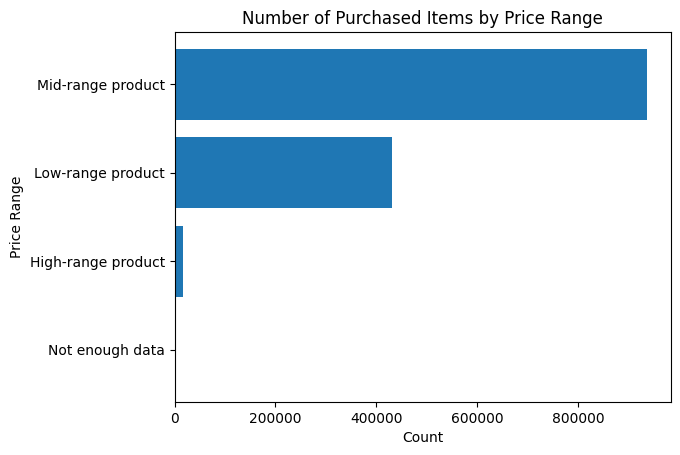

In [33]:
price_range_counts = df_instacart["price_range"].value_counts().sort_values()

plt.figure()
plt.barh(price_range_counts.index, price_range_counts.values)
plt.title("Number of Purchased Items by Price Range")
plt.xlabel("Count")
plt.ylabel("Price Range")
plt.show()

In [34]:
#Example 2: Reorder Rate by price_range
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

reorder_by_price_range

price_range
High-range product    0.579092
Low-range product     0.590833
Mid-range product     0.602527
Not enough data       0.670455
Name: reordered, dtype: float64

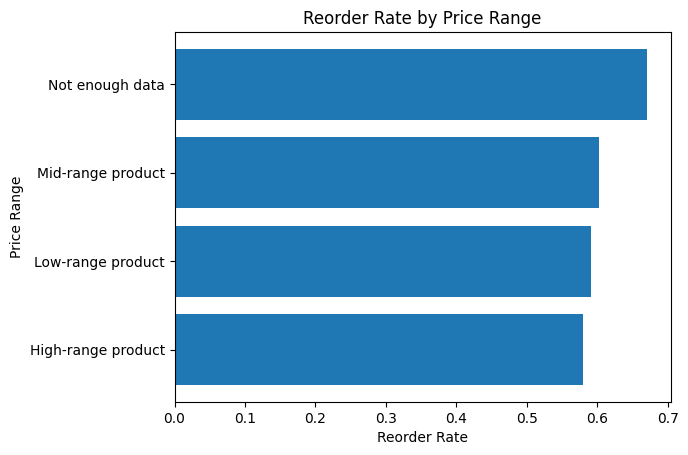

In [35]:
reorder_by_price_range = (
    df_instacart
    .groupby("price_range")["reordered"]
    .mean()
    .sort_values()
)

plt.figure()
plt.barh(reorder_by_price_range.index, reorder_by_price_range.values)
plt.title("Reorder Rate by Price Range")
plt.xlabel("Reorder Rate")
plt.ylabel("Price Range")
plt.show()

In [36]:
df_instacart.columns

Index(['order_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division', 'price_range',
       'price_range_loc', 'age_group', 'income_group', 'order_time_band',
       'expensive_product'],
      dtype='str')

In [37]:
#Example 3: Customer Counts by age_group
df_customers_unique = df_instacart[
    ["First Name", "Surname", "Age", "income", "age_group", "income_group", "region"]
].drop_duplicates()

df_customers_unique.head()

,First Name,Surname,Age,income,age_group,income_group,region
0,Linda,Nguyen,31,40423,Middle,Middle income,South
11,Norma,Chapman,68,64940,Senior,Middle income,West
42,Janet,Lester,75,115242,Senior,High income,West
51,Peter,Villegas,39,89095,Middle,High income,Northeast
60,Anna,Allison,32,88603,Middle,High income,South


In [47]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()
age_group_counts

age_group
Young     24682
Senior    44829
Middle    61698
Name: count, dtype: int64

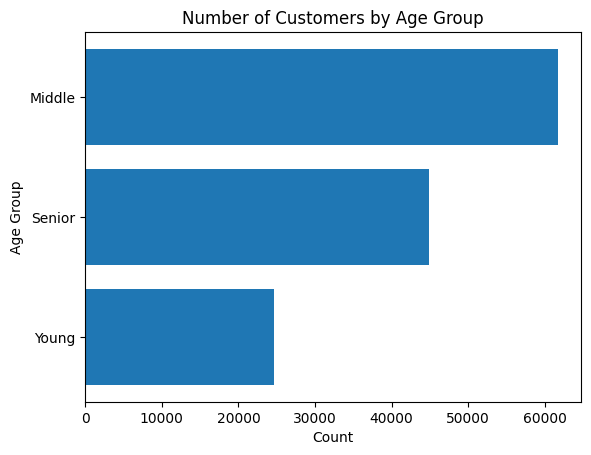

In [48]:
age_group_counts = df_customers_unique["age_group"].value_counts().sort_values()

plt.figure()
plt.barh(age_group_counts.index, age_group_counts.values)
plt.title("Number of Customers by Age Group")
plt.xlabel("Count")
plt.ylabel("Age Group")
plt.show()

In [ ]:
#Example 4: Average Income by age_group


In [ ]:
#Example 5: Orders by order_time_band


### Practice Tasks

In [38]:
#Task 1: Create a derived column called family_size_group based on n_dependants.
def family_size_group(n_dependants):
    if n_dependants == 0:
        return "No dependants"
    elif 1 <= n_dependants <= 5:
        return "Small family"
    else:
        return "Large family"

In [39]:
#Task 2: Create a derived column called senior_flag based on Age.
def senior_flag(age):
    if age >= 60:
        return "Senior"
    else:
        return "Not senior"

In [40]:
#Task 3։ Visualize the number of customers by income_group.

def income_group(income, low=30000, high=70000):
    if income < low:
        return "Low income"
    elif income < high:
        return "Middle income"
    else:
        return "High income"
    
df_instacart["income_group"] = df_instacart["income"].apply(income_group)
df_instacart["income_group"].value_counts(dropna=False)

income_group
High income      975334
Middle income    398848
Low income        10524
Name: count, dtype: int64

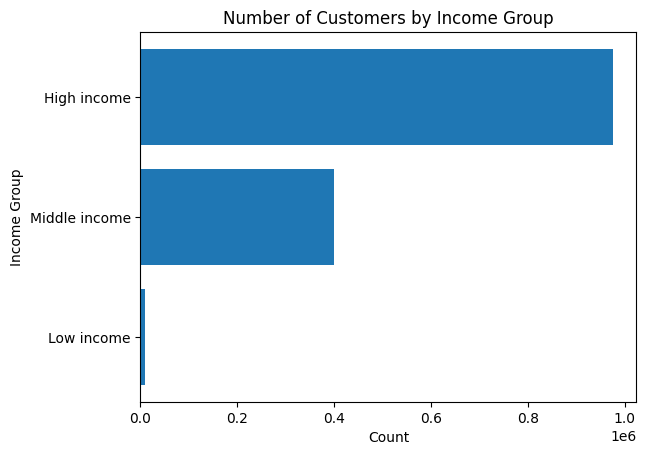

In [41]:
income_counts = df_instacart["income_group"].value_counts().sort_values()

plt.figure()
plt.barh(income_counts.index, income_counts.values)
plt.title("Number of Customers by Income Group")
plt.xlabel("Count")
plt.ylabel("Income Group")
plt.show()

In [42]:
#Task 4 Visualize the reorder rate by order_time_band.
reorder_rate = df_instacart.groupby("order_time_band")["reordered"].mean()
print(reorder_rate)

order_time_band
Afternoon    0.588812
Evening      0.593630
Morning      0.617444
Night        0.584850
Name: reordered, dtype: float64


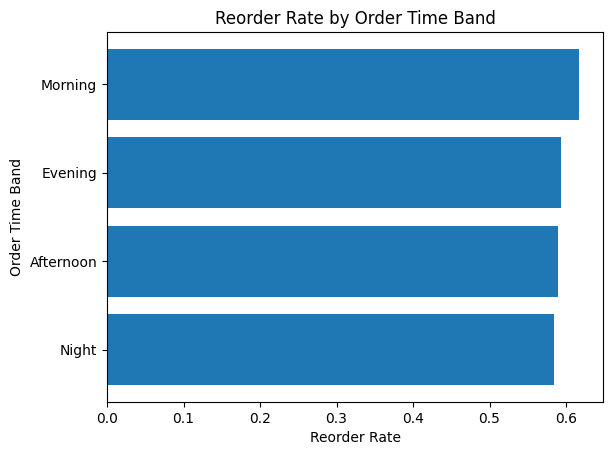

In [43]:
reorder_rate = df_instacart.groupby("order_time_band")["reordered"].mean().sort_values()

plt.figure()
plt.barh(reorder_rate.index, reorder_rate.values)
plt.title("Reorder Rate by Order Time Band")
plt.xlabel("Reorder Rate")
plt.ylabel("Order Time Band")
plt.show()

In [44]:
#Task 5: Create a flag variable on dow using both lambda and isin() methods
df_instacart["weekend_flag"] = df_instacart["order_dow"].apply(
    lambda x: 1 if x in [0, 6] else 0
)

In [45]:
df_instacart["weekend_flag"] = df_instacart["order_dow"].isin([0, 6]).astype(int)

In [46]:
print(df_instacart.columns)

Index(['order_id', 'eval_set', 'order_number', 'order_dow',
       'order_hour_of_day', 'days_since_prior_order', 'product_id',
       'add_to_cart_order', 'reordered', 'product_name', 'aisle_id',
       'department_id', 'prices', 'department', 'aisle', 'First Name',
       'Surname', 'Gender', 'state', 'Age', 'date_joined', 'n_dependants',
       'fam_status', 'income', 'region', 'division', 'price_range',
       'price_range_loc', 'age_group', 'income_group', 'order_time_band',
       'expensive_product', 'weekend_flag'],
      dtype='str')
